In [17]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [18]:
# Load Breast Cancer data
cancer = load_breast_cancer()
X = cancer.data  # features only (unsupervised)
df = pd.DataFrame(X, columns=cancer.feature_names)

# Display first 5 rows
print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [20]:
# Elbow Method
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Print the inertia values
for i, val in enumerate(inertia, start=1):
    print(f"Number of clusters = {i}, Inertia = {val:.2f}")

# Plot Elbow Method
plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method to find optimal clusters (Breast Cancer)")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.tight_layout()
plt.savefig("elbow_plot.png")
plt.close()

Number of clusters = 1, Inertia = 17070.00
Number of clusters = 2, Inertia = 11595.53
Number of clusters = 3, Inertia = 10061.80
Number of clusters = 4, Inertia = 9258.99
Number of clusters = 5, Inertia = 8558.66
Number of clusters = 6, Inertia = 7970.26
Number of clusters = 7, Inertia = 7540.32
Number of clusters = 8, Inertia = 7254.33
Number of clusters = 9, Inertia = 6837.63
Number of clusters = 10, Inertia = 6603.40


--- Calculating Silhouette Scores ---
Number of clusters (K) = 2 | Average Silhouette Score = 0.3434
Number of clusters (K) = 3 | Average Silhouette Score = 0.3144
Number of clusters (K) = 4 | Average Silhouette Score = 0.2833
Number of clusters (K) = 5 | Average Silhouette Score = 0.1582
Number of clusters (K) = 6 | Average Silhouette Score = 0.1604
Number of clusters (K) = 7 | Average Silhouette Score = 0.1532
Number of clusters (K) = 8 | Average Silhouette Score = 0.1472
Number of clusters (K) = 9 | Average Silhouette Score = 0.1470
Number of clusters (K) = 10 | Average Silhouette Score = 0.1367

Result: The Best K is 2 with an Average Silhouette Score of 0.3434



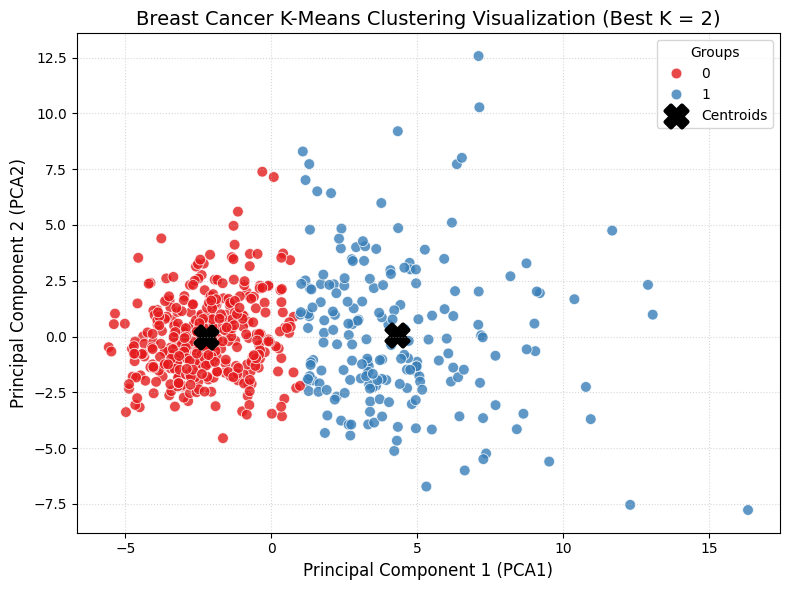

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# 1. Load the Breast Cancer Dataset
cancer = load_breast_cancer()
X = cancer.data
df = pd.DataFrame(X, columns=cancer.feature_names)

# 2. Feature Scaling (Essential for distance-based algorithms like K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Calculate Silhouette Scores to find the Best K
# Silhouette score requires at least 2 clusters and at most n_samples - 1
k_range = range(2, 11)
silhouette_scores = []

print("--- Calculating Silhouette Scores ---")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)

    # Calculate the average silhouette score for the current K
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)
    print(f"Number of clusters (K) = {k} | Average Silhouette Score = {score:.4f}")

# Automatically identify the best K based on the maximum silhouette score
best_k_index = np.argmax(silhouette_scores)
best_k = k_range[best_k_index]
best_score = silhouette_scores[best_k_index]

print(f"\nResult: The Best K is {best_k} with an Average Silhouette Score of {best_score:.4f}\n")

# 4. Train the Final K-Means Model using the Best K
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
final_clusters = final_kmeans.fit_predict(X_scaled)
df['Cluster'] = final_clusters

# 5. Dimensionality Reduction with PCA for 2D Visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

# 6. Visualize the Clusters for the Best K
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=df,
    palette='Set1',
    alpha=0.8,
    edgecolor='w',
    s=60
)

# Plot the cluster centroids in the PCA space
centroids = final_kmeans.cluster_centers_
centroids_pca = pca.transform(centroids)
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker='X',
    s=250,
    linewidths=3,
    color='black',
    label='Centroids'
)

plt.title(f"Breast Cancer K-Means Clustering Visualization (Best K = {best_k})", fontsize=14)
plt.xlabel("Principal Component 1 (PCA1)", fontsize=12)
plt.ylabel("Principal Component 2 (PCA2)", fontsize=12)
plt.legend(title="Groups")
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

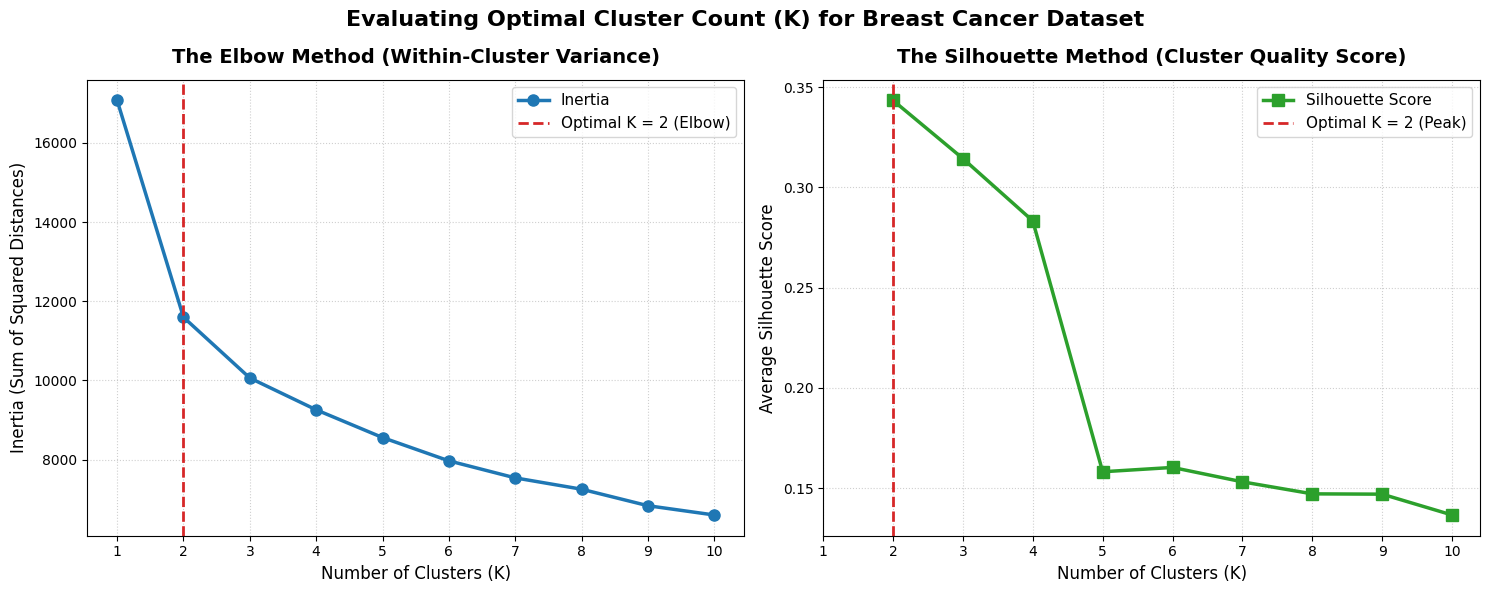

In [25]:
# 1. Load and scale the Breast Cancer dataset
cancer = load_breast_cancer()
X = cancer.data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Compute metrics across a range of clusters (K=1 to 10)
k_range = range(1, 11)
inertia_values = []
silhouette_scores = []

# K=1 has to be done separately because silhouette score requires at least 2 clusters
kmeans_k1 = KMeans(n_clusters=1, random_state=42, n_init=10).fit(X_scaled)
inertia_values.append(kmeans_k1.inertia_)
silhouette_scores.append(0)  # Placeholder for K=1

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia_values.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# 3. Create a high-quality side-by-side visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- Left Plot: Elbow Method ---
ax1.plot(k_range, inertia_values, marker='o', color='#1f77b4', linewidth=2.5, markersize=8, label='Inertia')
ax1.axvline(x=2, color='#d62728', linestyle='--', linewidth=2, label='Optimal K = 2 (Elbow)')
ax1.set_title('The Elbow Method (Within-Cluster Variance)', fontsize=14, fontweight='bold', pad=12)
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia (Sum of Squared Distances)', fontsize=12)
ax1.set_xticks(k_range)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(fontsize=11, loc='upper right')

# --- Right Plot: Silhouette Score Method ---
# We skip K=1 for plotting the silhouette curve since it's undefined
ax2.plot(range(2, 11), silhouette_scores[1:], marker='s', color='#2ca02c', linewidth=2.5, markersize=8, label='Silhouette Score')
ax2.axvline(x=2, color='#d62728', linestyle='--', linewidth=2, label='Optimal K = 2 (Peak)')
ax2.set_title('The Silhouette Method (Cluster Quality Score)', fontsize=14, fontweight='bold', pad=12)
ax2.set_xlabel('Number of Clusters (K)', fontsize=12)
ax2.set_ylabel('Average Silhouette Score', fontsize=12)
ax2.set_xticks(k_range)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(fontsize=11, loc='upper right')

# 4. Global configurations and save/display
plt.suptitle('Evaluating Optimal Cluster Count (K) for Breast Cancer Dataset', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

--- Evaluation Across Cluster Range ---
K = 2 | Inertia = 222.36 | Silhouette Score = 0.5818
K = 3 | Inertia = 139.82 | Silhouette Score = 0.4599
K = 4 | Inertia = 114.09 | Silhouette Score = 0.3869
K = 5 | Inertia = 90.93 | Silhouette Score = 0.3459
K = 6 | Inertia = 81.54 | Silhouette Score = 0.3171
K = 7 | Inertia = 72.63 | Silhouette Score = 0.3202
K = 8 | Inertia = 62.54 | Silhouette Score = 0.3387
K = 9 | Inertia = 55.12 | Silhouette Score = 0.3424
K = 10 | Inertia = 47.39 | Silhouette Score = 0.3518

[SELECTED]: Number of Clusters set to K = 3
Silhouette Score for K = 3: 0.4599


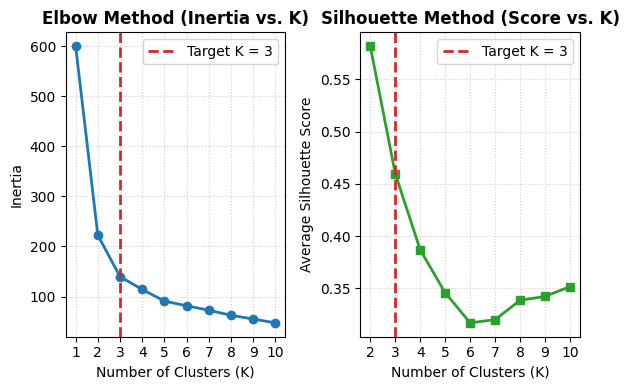

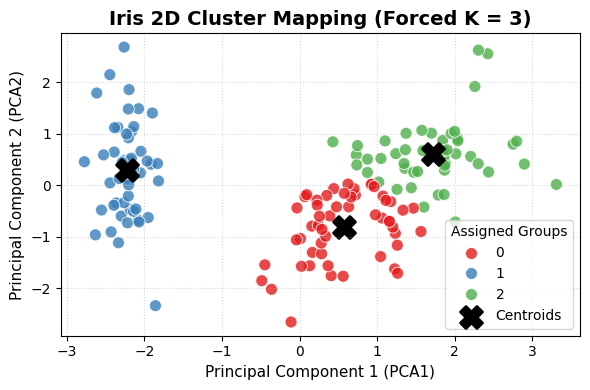

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# =====================================================================
# 1. LOAD AND PREPARE DATA
# =====================================================================
iris = load_iris()
X = iris.data
feature_names = iris.feature_names

# Scale features so they have equal weight in distance calculations
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =====================================================================
# 2. EVALUATE MULTIPLE K VALUES (FOR FINDING METRICS)
# =====================================================================
k_range = range(2, 11)
inertia_values = []
silhouette_scores = []

# Fetch baseline inertia for K=1
inertia_k1 = KMeans(n_clusters=1, random_state=42, n_init=10).fit(X_scaled).inertia_
all_inertia = [inertia_k1]

print("--- Evaluation Across Cluster Range ---")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    all_inertia.append(kmeans.inertia_)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"K = {k} | Inertia = {kmeans.inertia_:.2f} | Silhouette Score = {score:.4f}")

# =====================================================================
# 3. APPLY K-MEANS WITH EXACTLY K = 3 CLUSTERS
# =====================================================================
# Setting the explicit number of clusters to 3
target_k = 3
final_kmeans = KMeans(n_clusters=target_k, random_state=42, n_init=10)
final_clusters = final_kmeans.fit_predict(X_scaled)

# Calculate the precise silhouette score for 3 clusters
silhouette_k3 = silhouette_score(X_scaled, final_clusters)
print(f"\n[SELECTED]: Number of Clusters set to K = {target_k}")
print(f"Silhouette Score for K = 3: {silhouette_k3:.4f}")

# Create a DataFrame to hold features, cluster IDs, and PCA projections
df = pd.DataFrame(X, columns=feature_names)
df['Cluster'] = final_clusters

# =====================================================================
# 4. DIMENSIONALITY REDUCTION (PCA) FOR 2D VISUALIZATION
# =====================================================================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

# =====================================================================
# 5. GENERATE PLOTS
# =====================================================================
# Plot A: Metric Evaluation Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6,4))

# Elbow plot highlighting K=3
ax1.plot(range(1, 11), all_inertia, marker='o', color='#1f77b4', linewidth=2)
ax1.axvline(x=target_k, color='#d62728', linestyle='--', linewidth=2, label=f'Target K = {target_k}')
ax1.set_title('Elbow Method (Inertia vs. K)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia')
ax1.set_xticks(range(1, 11))
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend()

# Silhouette plot highlighting K=3
ax2.plot(k_range, silhouette_scores, marker='s', color='#2ca02c', linewidth=2)
ax2.axvline(x=target_k, color='#d62728', linestyle='--', linewidth=2, label=f'Target K = {target_k}')
ax2.set_title('Silhouette Method (Score vs. K)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Average Silhouette Score')
ax2.set_xticks(k_range)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

# Plot B: Final 3-Cluster Scatter Grid
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=df,
    palette='Set1',
    s=75,
    alpha=0.8,
    edgecolor='w'
)

# Project the cluster center-points (centroids) onto the 2D graph space
centroids = final_kmeans.cluster_centers_
centroids_pca = pca.transform(centroids)
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker='X',
    s=250,
    color='black',
    linewidths=2,
    label='Centroids'
)

plt.title(f'Iris 2D Cluster Mapping (Forced K = {target_k})', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1 (PCA1)', fontsize=11)
plt.ylabel('Principal Component 2 (PCA2)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(title='Assigned Groups')
plt.tight_layout()
plt.show()